# Notebook 3 — Three-way test, done properly: A (Metis as released) vs B (normal eraser) vs C (erase only on updates)

**Why a new notebook?** In Notebook 2 every version scored ~90% on familiar names, but only ~20–35% on
**new names and new wordings**. The memory had mostly learned the 40 training names, not a general way to store facts.
So those numbers could not be trusted.

**What is fixed in this notebook:**

| Problem in Notebook 2 | Fix here |
|---|---|
| Only 40 training names | **400 full names** ("Maria Chen") built from 42 first × 42 last names. Test uses 100 people whose first AND last names are never seen in training. |
| Only 3 wordings per sentence type | **6 statement, 5 update, 4 question wordings** per attribute for training; 2 separate unseen wordings each for testing. |
| Sentence vector skipped the first token, which (Qwen adds no start token) was usually the **person's name** | A fixed prefix `Sentence:` is added and skipped instead, so the name is always kept. The vector = average of all sentence tokens **+ the last token**. |
| Test used training names by mistake (`TEST_SPLIT = "train"`) | Four fixed test conditions, always all reported: seen, new names, new wordings, **new names + new wordings (the honest test)**. All main results use the honest test. |
| Loss drifted late in training | Learning rate warm-up + cosine decay, small input dropout (same for A, B, C). |
| Did C's gate react to meaning or just to words like "moved"? | New **silent-update test**: the change is written as a plain statement. |

A **quick check** (Cell 12) trains one small model first. If even that fails on new names, the notebook stops
early instead of wasting an hour.

**The three memory versions (everything else identical):**

| Version | What it does |
|---|---|
| **A** | Metis as released: keys divided by √(memory size), so the eraser is almost off. One knob (β) for writing and erasing. |
| **B** | Same as A but keys have normal size (length 1), so the eraser really works. Still one knob. |
| **C** | Like B, but with **two knobs**: one for writing and a separate learned one for erasing. |

**Kaggle settings:** GPU T4 · Internet On · Secret `HF_TOKEN` · run all cells top to bottom.
Time: about 10–15 min to encode sentences, ~3 min quick check, then ~9–11 min per run × 9 runs → **roughly 1.5–2 hours**.
Results are saved after every run; if the session stops, run everything again and finished runs are skipped.

In [1]:
# CELL 1 -- Install the exact Transformers version Metis was saved with
!pip install -q "transformers==5.4.0" accelerate

import transformers
from transformers.models.auto.configuration_auto import CONFIG_MAPPING_NAMES

print("Transformers version:", transformers.__version__)
print("Loaded from        :", transformers.__file__)

qwen_models = []
for model_type in CONFIG_MAPPING_NAMES:
    if model_type.startswith("qwen"):
        qwen_models.append(model_type)
print("Qwen models this version knows:", qwen_models)

if "qwen3_5" in qwen_models:
    print("\nOK: qwen3_5 is supported. Continue with Cell 2.")
else:
    print("\nPROBLEM: qwen3_5 is NOT supported. Share this output.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 59.2 MB/s eta 0:00:0000:010:01
Transformers version: 5.4.0
Loaded from        : /usr/local/lib/python3.12/dist-packages/transformers/__init__.py
Qwen models this version knows: ['qwen2', 'qwen2_5_omni', 'qwen2_5_vl', 'qwen2_5_vl_text', 'qwen2_audio', 'qwen2_audio_encoder', 'qwen2_moe', 'qwen2_vl', 'qwen2_vl_text', 'qwen3', 'qwen3_5', 'qwen3_5_moe', 'qwen3_5_moe_text', 'qwen3_5_text', 'qwen3_moe', 'qwen3_next', 'qwen3_omni_moe', 'qwen3_vl', 'qwen3_vl_moe', 'qwen3_vl_moe_text', 'qwen3_vl_text']

OK: qwen3_5 is supported. Continue with Cell 2.


In [2]:
# CELL 2 -- HuggingFace login
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

try:
    user_secrets = UserSecretsClient()
    secret_value_0 = user_secrets.get_secret("HF_TOKEN")
    login(secret_value_0)
    print("HuggingFace login done")
except Exception as error:
    print("Login skipped (Qwen2.5 is public, so this is usually fine).")
    print("Reason:", error)

HuggingFace login done


In [3]:
# CELL 3 -- Imports + GPU + settings
import os
import json
import math
import random
import time
import gc
import shutil

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm

OUTPUT_DIR = "/kaggle/working/metis_three_way_v2"   # NEW folder, so Notebook 2 results are never mixed in
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PyTorch : {torch.__version__}")
if DEVICE == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU     : none (training will be very slow)")
print(f"Output  : {OUTPUT_DIR}")

CONFIG = {
    # Frozen language model that turns sentences into vectors (never trained here)
    "feature_model"          : "Qwen/Qwen2.5-1.5B-Instruct",
    "feature_layer"          : 18,        # which hidden layer to read (Qwen2.5-1.5B has 28)
    "encode_batch_size"      : 128,
    "encode_prefix"          : "Sentence:",   # fixed start; its tokens are skipped when averaging

    # People
    "n_train_people"         : 400,       # full names made from TRAIN first x TRAIN last names
    "n_test_people"          : 100,       # full names made from TEST first x TEST last names (never seen)
    "n_wording_probe_people" : 60,        # training people also written with the unseen wordings
    "pool_seed"              : 0,         # fixes which people and wordings are chosen

    # Memory settings (copied from Metis where possible)
    "memory_size"            : 512,
    "update_ratio"           : 0.9,       # same as Metis config.json
    "gate_start_logit"       : 4.0,       # gates start at sigmoid(4) = 0.98
    "feature_dropout"        : 0.1,       # small noise during training only (same for A, B, C)

    # Story (episode) shape used in training and in the main tests
    "people_per_episode"     : 2,
    "facts_per_person"       : 4,
    "fillers_per_episode"    : 2,
    "max_updates_per_episode": 2,

    # Training (identical for A, B and C)
    "train_steps"            : 3000,
    "warmup_steps"           : 100,
    "batch_size"             : 64,
    "learning_rate"          : 0.001,
    "print_every"            : 250,
    "seeds"                  : [1, 2, 3],
    "versions"               : ["A", "B", "C"],

    # Quick check before the long runs
    "quick_check_steps"      : 800,
    "quick_check_floor"      : 40.0,      # stop if B keeps < this % of unchanged facts on the honest test
    "stop_if_quick_check_fails": True,

    # Testing
    "test_seed"              : 999,       # FIXED: every version is tested on the same stories
    "n_test_episodes"        : 2000,      # per condition; each test story has exactly ONE update
    "n_long_episodes"        : 500,
    "long_people"            : 5,         # long story: 5 people x 6 facts + 10 fillers = 40 writes
    "long_fillers"           : 10,
    "long_checkpoints"       : [1, 5, 10, 20, 30, 40],
    "eval_batch_size"        : 100,

    # Decision rules, written BEFORE seeing results (percentage points)
    "generalization_floor"   : 60.0,      # every version must keep >= this % of unchanged facts (honest test)
    "problem_threshold"      : 10.0,      # B must beat A on updates by at least this much
    "gain_threshold"         : 10.0,      # C must beat A on updates by at least this much
    "damage_tolerance"       : 3.0,       # C may lose at most this much on other facts
    "retention_margin"       : 5.0,       # re-test of Notebook 2: C beats B on first fact after 40 by this much

    # Files
    "features_file"          : f"{OUTPUT_DIR}/sentence_features.pt",
    "results_file"           : f"{OUTPUT_DIR}/results.json",
    "loss_file"              : f"{OUTPUT_DIR}/loss_curves.json",
}

VERSION_DESCRIPTIONS = {
    "A": "A: Metis as released (tiny keys, eraser ~off)",
    "B": "B: normal keys (eraser on, one knob)",
    "C": "C: separate erase knob",
}
VERSION_COLORS = {"A": "tab:gray", "B": "tab:orange", "C": "tab:green"}

# Every metric: (short name, what it measures, which direction is good)
METRIC_GUIDE = {
    "update_correct": ("Updated fact correct (%)",
                       "A fact changed during the story (e.g. the person moved). How often the memory gives the NEW value.",
                       "HIGHER is better"),
    "update_gave_old": ("Gave the OLD value (%)",
                        "For the same changed facts: how often the memory gives the value that was replaced "
                        "(a stale memory the eraser failed to remove).",
                        "LOWER is better"),
    "same_person_kept": ("Same-person facts kept (%)",
                         "Facts that did NOT change but belong to the person who had an update. "
                         "Shows whether erasing damaged that person's other facts.",
                         "HIGHER is better"),
    "unchanged_kept": ("All unchanged facts kept (%)",
                       "Every fact that did not change, for both people. General memory quality.",
                       "HIGHER is better"),
    "long_first_after_40": ("First fact after 40 writes (%)",
                            "Long story of 40 sentences: is the very first fact still recalled at the end? "
                            "Measures long-range forgetting.",
                            "HIGHER is better"),
    "long_all_final": ("All 30 facts at end of long story (%)",
                       "Long story: how many of the 30 facts are recalled after all 40 sentences.",
                       "HIGHER is better"),
    "erase_on_filler": ("Erase on filler sentences (0 to 0.9)",
                        "How strongly the memory erases when the sentence is small talk ('The sky looks cloudy.').",
                        "NO better/worse (diagnostic only)"),
    "erase_on_new_fact": ("Erase on NEW facts (0 to 0.9)",
                          "Erasing while storing a brand-new fact. Nothing should be removed, and because keys "
                          "overlap, erasing here can damage older facts.",
                          "LOWER is better"),
    "erase_on_update": ("Erase on UPDATES (0 to 0.9)",
                        "Erasing when a fact changes. This is exactly when the old value should be removed.",
                        "HIGHER is better"),
    "silent_update_correct": ("Silent update correct (%)",
                              "Same as 'Updated fact correct', but the change is written as a plain statement "
                              "('Rafi Singh lives in Oslo.') with no word like 'moved' or 'now'.",
                              "HIGHER is better"),
    "silent_update_gave_old": ("Silent update gave OLD value (%)",
                               "For silent updates: how often the replaced value is given.",
                               "LOWER is better"),
    "silent_erase_on_update": ("Erase on SILENT updates (0 to 0.9)",
                               "Erase strength on plainly-worded changes. High = the model notices the change from "
                               "meaning. Low = it only reacts to words like 'moved' or 'now'.",
                               "HIGHER is better"),
    "generalization_gap": ("Generalization gap (points)",
                           "Seen-names score minus honest-test score. Small gap = the memory learned a general "
                           "skill; big gap = it memorised the training names.",
                           "LOWER is better"),
    "retention_curve": ("First fact recalled after N writes (%)",
                        "Long story: the first fact is asked again after 1, 5, 10, 20, 30 and 40 sentences.",
                        "HIGHER is better"),
    "paired_difference": ("Paired difference (points)",
                          "Same seed, same test stories: version X minus version Y. Positive = X scored more. "
                          "For 'Gave the OLD value' and 'Erase on NEW facts' a NEGATIVE difference is the good one.",
                          "see each metric"),
}


def print_metric_guide(metric_keys, title):
    print("=" * 96)
    print(title)
    print("-" * 96)
    print("WHAT THE NUMBERS MEAN:")
    for key in metric_keys:
        short_name, meaning, direction = METRIC_GUIDE[key]
        print(f"  * {short_name}   -->  {direction}")
        print(f"      {meaning}")
    print("-" * 96)


print("Settings ready.")

PyTorch : 2.10.0+cu128
GPU     : Tesla T4
VRAM    : 15.6 GB
Output  : /kaggle/working/metis_three_way_v2
Settings ready.


In [4]:
# CELL 4 -- Vocabulary: names, facts, sentence wordings
# Names: a person is "First Last". Training and test use completely different first AND last names.
# Wordings: "train" wordings are used in training; "test" wordings are NEVER seen in training.

TRAIN_FIRST_NAMES = ["Alice", "Rahim", "Maria", "Kenji", "Fatima", "Omar", "Lena", "Arjun", "Sofia", "Yusuf",
                     "Hana", "Diego", "Nora", "Tariq", "Emma", "Ravi", "Chloe", "Ahmed", "Mei", "Lucas",
                     "Priya", "Jonas", "Amara", "Ivan", "Leila", "Mateo", "Sara", "Kofi", "Anya", "Bilal",
                     "Grace", "Hiro", "Zara", "Felix", "Nadia", "Pablo", "Ines", "Sami", "Tara", "Victor",
                     "Olga", "Samir"]
TEST_FIRST_NAMES = ["Rafi", "Elena", "Musa", "Clara", "Joon", "Selin", "Adnan", "Maya", "Tomas", "Rina",
                    "Karim", "Julia", "Nikhil"]
TRAIN_LAST_NAMES = ["Chen", "Silva", "Khan", "Novak", "Okafor", "Garcia", "Tanaka", "Rossi", "Haddad", "Kowalski",
                    "Mensah", "Patel", "Nguyen", "Schmidt", "Moreau", "Ivanov", "Costa", "Hansen", "Rahman", "Suzuki",
                    "Lopez", "Ali", "Petrov", "Murphy", "Fischer", "Kim", "Yilmaz", "Das", "Mendes", "Olsen",
                    "Bauer", "Sato", "Diaz", "Kaya", "Wright", "Park", "Hossain", "Lindqvist", "Mwangi", "Romano",
                    "Castro", "Weber"]
TEST_LAST_NAMES = ["Morales", "Jensen", "Chowdhury", "Adeyemi", "Takahashi", "Russo", "Nakamura", "Dubois",
                   "Ortega", "Singh", "Varga", "Lee", "Popescu"]

assert len(set(TRAIN_FIRST_NAMES) & set(TEST_FIRST_NAMES)) == 0, "first names overlap"
assert len(set(TRAIN_LAST_NAMES) & set(TEST_LAST_NAMES)) == 0, "last names overlap"


def with_article(value):
    if value[0].lower() in "aeiou":
        return "an " + value
    return "a " + value


# {name} = full name, {value} = the fact, {a_value} = the fact with "a"/"an"
ATTRIBUTES = {
    "city": {
        "values": ["Dhaka", "Tokyo", "Paris", "London", "Cairo", "Lima", "Oslo", "Berlin", "Madrid", "Rome",
                   "Nairobi", "Sydney", "Toronto", "Chicago", "Mumbai", "Seoul", "Bangkok", "Dubai", "Lisbon", "Vienna"],
        "statements": {"train": ["{name} lives in {value}.", "{name}'s home is in {value}.", "{name} is based in {value}.",
                                 "{name} has an apartment in {value}.", "{name} spends most of the year in {value}.",
                                 "The city {name} calls home is {value}."],
                       "test": ["{name} resides in {value}.", "{name}'s address is in {value}."]},
        "updates": {"train": ["{name} moved to {value}.", "{name} has relocated to {value}.", "{name} now lives in {value} instead.",
                              "{name} left the old city and settled in {value}.", "These days {name} is living in {value}."],
                    "test": ["{name} recently packed up and settled in {value}.", "{name} changed cities and is now in {value}."]},
        "questions": {"train": ["Where does {name} live?", "Which city is {name} based in?", "What city is {name}'s home?",
                                "Where is {name} living?"],
                      "test": ["In which city does {name} reside?", "What is {name}'s city of residence?"]},
    },
    "job": {
        "values": ["doctor", "teacher", "pilot", "chef", "nurse", "lawyer", "farmer", "dentist", "architect", "plumber",
                   "journalist", "engineer", "painter", "banker", "librarian", "firefighter", "baker", "pharmacist",
                   "electrician", "photographer"],
        "statements": {"train": ["{name} works as {a_value}.", "{name} is {a_value} by profession.", "{name} earns a living as {a_value}.",
                                 "{name} has a job as {a_value}.", "By trade, {name} is {a_value}.",
                                 "{name} trained as {a_value} and works as one."],
                       "test": ["{name} is employed as {a_value}.", "{name} makes a career as {a_value}."]},
        "updates": {"train": ["{name} changed careers and is now {a_value}.", "{name} now works as {a_value}.",
                              "{name} quit the old job and became {a_value}.", "{name} has a new job as {a_value}.",
                              "After a career change, {name} is {a_value}."],
                    "test": ["{name} switched professions to become {a_value}.", "{name} retrained and now works as {a_value}."]},
        "questions": {"train": ["What is {name}'s job?", "What does {name} do for work?", "What is {name}'s occupation?",
                                "How does {name} earn a living?"],
                      "test": ["What is {name}'s profession?", "What kind of work does {name} do?"]},
    },
    "food": {
        "values": ["pizza", "sushi", "biryani", "pasta", "tacos", "ramen", "curry", "salad", "burgers", "dumplings",
                   "paella", "kebab", "noodles", "pancakes", "falafel", "lasagna", "steak", "soup", "sandwiches", "waffles"],
        "statements": {"train": ["{name}'s favorite food is {value}.", "{name} loves eating {value}.",
                                 "{name} enjoys {value} more than any other dish.", "Nothing beats {value} for {name}.",
                                 "{name} would eat {value} every day.", "{name}'s go-to meal is {value}."],
                       "test": ["{name}'s top dish is {value}.", "{name} craves {value} above all else."]},
        "updates": {"train": ["{name}'s favorite food is now {value}.", "These days {name} prefers {value} over the old favorite.",
                              "{name} changed favorite food to {value}.", "{name} has a new favorite dish: {value}.",
                              "Lately {name} likes {value} best."],
                    "test": ["{name} has grown tired of the old dish and now craves {value}.",
                             "{name}'s taste changed, and {value} is the new favorite."]},
        "questions": {"train": ["What is {name}'s favorite food?", "Which dish does {name} like best?",
                                "What does {name} love to eat?", "What is {name}'s go-to meal?"],
                      "test": ["What food does {name} love most?", "Which meal is {name}'s top choice?"]},
    },
    "pet": {
        "values": ["cat", "dog", "parrot", "rabbit", "hamster", "turtle", "goldfish", "horse", "snake", "lizard",
                   "ferret", "pony", "canary", "hedgehog", "chinchilla", "guinea pig", "iguana", "frog", "tortoise", "gecko"],
        "statements": {"train": ["{name} has a pet {value}.", "{name} owns {a_value}.", "{name} takes care of a pet {value}.",
                                 "{name} lives with {a_value}.", "{name}'s pet is {a_value}.", "At home, {name} looks after {a_value}."],
                       "test": ["{name} keeps {a_value} at home.", "{name} is the proud owner of {a_value}."]},
        "updates": {"train": ["{name} now has a pet {value} instead.", "{name} gave away the old pet and adopted {a_value}.",
                              "{name}'s pet is now {a_value}.", "{name} got a new pet, {a_value}.",
                              "{name} replaced the old pet with {a_value}."],
                    "test": ["{name} rehomed the previous pet and got {a_value}.",
                             "{name} no longer has the old pet and now owns {a_value}."]},
        "questions": {"train": ["What pet does {name} have?", "What animal does {name} own?", "What is {name}'s pet?",
                                "Which animal lives with {name}?"],
                      "test": ["What kind of pet does {name} keep?", "What animal does {name} look after?"]},
    },
    "color": {
        "values": ["red", "blue", "green", "yellow", "purple", "orange", "pink", "brown", "black", "white",
                   "gray", "teal", "maroon", "navy", "gold", "silver", "beige", "violet", "olive", "cyan"],
        "statements": {"train": ["{name}'s favorite color is {value}.", "{name} likes the color {value} best.",
                                 "{name} always picks {value} as a color.", "{name} loves the color {value}.",
                                 "Most of {name}'s clothes are {value}.", "{name}'s favorite shade is {value}."],
                       "test": ["{name} prefers the color {value}.", "{name} is drawn to the color {value}."]},
        "updates": {"train": ["{name}'s favorite color is now {value}.", "{name} changed favorite color to {value}.",
                              "Lately {name} likes {value} better than the old color.",
                              "{name} now prefers {value} to any other color.", "{name} has a new favorite color: {value}."],
                    "test": ["{name} no longer likes the old color and now chooses {value}.",
                             "{name}'s color taste shifted to {value}."]},
        "questions": {"train": ["What is {name}'s favorite color?", "Which color does {name} like best?",
                                "What color does {name} love?", "What is {name}'s favorite shade?"],
                      "test": ["What color does {name} prefer?", "Which color is {name} drawn to?"]},
    },
    "hobby": {
        "values": ["chess", "tennis", "painting", "hiking", "swimming", "cycling", "gardening", "fishing", "knitting", "dancing",
                   "boxing", "surfing", "archery", "pottery", "skating", "rowing", "climbing", "sailing", "golf", "yoga"],
        "statements": {"train": ["{name} enjoys {value}.", "{name}'s hobby is {value}.", "In free time, {name} does {value}.",
                                 "{name} spends evenings on {value}.", "{name} is passionate about {value}.",
                                 "{name} relaxes by doing {value}."],
                       "test": ["{name} spends weekends on {value}.", "{name}'s favorite pastime is {value}."]},
        "updates": {"train": ["{name} has switched to {value} as a hobby.", "{name}'s hobby is now {value}.",
                              "{name} stopped the old hobby and took up {value}.", "{name} recently started {value} instead.",
                              "{name} gave up the old hobby for {value}."],
                    "test": ["{name} dropped the previous hobby in favor of {value}.",
                             "{name} lost interest in the old hobby and picked up {value}."]},
        "questions": {"train": ["What is {name}'s hobby?", "What does {name} do for fun?", "How does {name} spend free time?",
                                "What is {name} passionate about?"],
                      "test": ["Which hobby does {name} have?", "What pastime does {name} enjoy?"]},
    },
}
ATTRIBUTE_NAMES = list(ATTRIBUTES.keys())

FILLERS = {
    "train": ["The weather is nice today.", "I had coffee this morning.", "The train was late again.",
              "We watched a movie last night.", "The meeting ran long.", "It rained in the afternoon.",
              "The shop closes at eight.", "My phone battery is low.", "The park was crowded.",
              "Dinner was delicious.", "The bus stop moved last week.", "I finished reading a book.",
              "The internet was slow today.", "We cleaned the kitchen.", "The music was loud.",
              "The elevator is broken.", "Someone left the window open.", "The coffee machine is empty.",
              "The street was very quiet.", "My shoes got wet."],
    "test": ["The sky looks cloudy.", "Traffic was heavy downtown.", "The library was quiet.",
             "Someone knocked on the door.", "The soup needed more salt.", "The printer ran out of paper.",
             "The clock on the wall stopped.", "A dog barked outside."],
}

# Safety check: no test wording is also a training wording
for attribute_name in ATTRIBUTE_NAMES:
    for part in ["statements", "updates", "questions"]:
        overlap = set(ATTRIBUTES[attribute_name][part]["train"]) & set(ATTRIBUTES[attribute_name][part]["test"])
        assert len(overlap) == 0, f"wording overlap in {attribute_name}/{part}: {overlap}"
assert len(set(FILLERS["train"]) & set(FILLERS["test"])) == 0

print("Attributes:", ATTRIBUTE_NAMES)
print(f"First names: {len(TRAIN_FIRST_NAMES)} train / {len(TEST_FIRST_NAMES)} test | "
      f"Last names: {len(TRAIN_LAST_NAMES)} train / {len(TEST_LAST_NAMES)} test")

Attributes: ['city', 'job', 'food', 'pet', 'color', 'hobby']
First names: 42 train / 13 test | Last names: 42 train / 13 test


In [5]:
# CELL 5 -- Choose the people and build the list of sentences
# Every (person, attribute, value) gets ONE sentence per wording set, using a randomly chosen template.
# This keeps the number of sentences small enough to encode, while 400 people give lots of variety.

pool_rng = random.Random(CONFIG["pool_seed"])

all_train_people = [f"{first} {last}" for first in TRAIN_FIRST_NAMES for last in TRAIN_LAST_NAMES]
all_test_people = [f"{first} {last}" for first in TEST_FIRST_NAMES for last in TEST_LAST_NAMES]
TRAIN_PEOPLE = sorted(pool_rng.sample(all_train_people, CONFIG["n_train_people"]))
TEST_PEOPLE = sorted(pool_rng.sample(all_test_people, CONFIG["n_test_people"]))
WORDING_PROBE_PEOPLE = sorted(pool_rng.sample(TRAIN_PEOPLE, CONFIG["n_wording_probe_people"]))

ALL_SENTENCES = []
SENTENCE_TO_ID = {}
FACT_SENTENCE = {}        # (person, attribute, value, "statement"/"update", wording) -> sentence id
QUESTION_SENTENCES = {}   # (person, attribute, wording) -> list of sentence ids
FILLER_SENTENCES = {}     # wording -> list of sentence ids
TRAINING_SENTENCE_IDS = set()


def add_sentence(text):
    if text not in SENTENCE_TO_ID:
        SENTENCE_TO_ID[text] = len(ALL_SENTENCES)
        ALL_SENTENCES.append(text)
    return SENTENCE_TO_ID[text]


def add_person(person, wording, used_in_training):
    for attribute_name in ATTRIBUTE_NAMES:
        attribute = ATTRIBUTES[attribute_name]
        for value in attribute["values"]:
            for kind, template_group in [("statement", "statements"), ("update", "updates")]:
                template = pool_rng.choice(attribute[template_group][wording])
                text = template.format(name=person, value=value, a_value=with_article(value))
                sentence_id = add_sentence(text)
                FACT_SENTENCE[(person, attribute_name, value, kind, wording)] = sentence_id
                if used_in_training:
                    TRAINING_SENTENCE_IDS.add(sentence_id)
        question_ids = []
        for template in attribute["questions"][wording]:
            sentence_id = add_sentence(template.format(name=person))
            question_ids.append(sentence_id)
            if used_in_training:
                TRAINING_SENTENCE_IDS.add(sentence_id)
        QUESTION_SENTENCES[(person, attribute_name, wording)] = question_ids


for person in TRAIN_PEOPLE:
    add_person(person, "train", used_in_training=True)
for person in WORDING_PROBE_PEOPLE:
    add_person(person, "test", used_in_training=False)
for person in TEST_PEOPLE:
    add_person(person, "train", used_in_training=False)
    add_person(person, "test", used_in_training=False)
for wording in ["train", "test"]:
    FILLER_SENTENCES[wording] = [add_sentence(text) for text in FILLERS[wording]]
TRAINING_SENTENCE_IDS.update(FILLER_SENTENCES["train"])

ANSWERS = []
ANSWER_TO_ID = {}
for attribute_name in ATTRIBUTE_NAMES:
    for value in ATTRIBUTES[attribute_name]["values"]:
        ANSWER_TO_ID[value] = len(ANSWERS)
        ANSWERS.append(value)

# The four test conditions
CONDITIONS = {
    "seen":         {"people": TRAIN_PEOPLE,         "wording": "train", "label": "Seen names + seen wordings (new stories)"},
    "new_names":    {"people": TEST_PEOPLE,          "wording": "train", "label": "NEW names + seen wordings"},
    "new_wordings": {"people": WORDING_PROBE_PEOPLE, "wording": "test",  "label": "Seen names + NEW wordings"},
    "honest":       {"people": TEST_PEOPLE,          "wording": "test",  "label": "NEW names + NEW wordings (honest test)"},
}
CONDITION_ORDER = ["seen", "new_names", "new_wordings", "honest"]

print(f"Train people: {len(TRAIN_PEOPLE)} | Test people: {len(TEST_PEOPLE)} | Wording-probe people: {len(WORDING_PROBE_PEOPLE)}")
print(f"Different sentences to encode: {len(ALL_SENTENCES):,} (used in training: {len(TRAINING_SENTENCE_IDS):,})")
print(f"Possible answers: {len(ANSWERS)}")
print("Example train people:", TRAIN_PEOPLE[:4])
print("Example test people :", TEST_PEOPLE[:4])

Train people: 400 | Test people: 100 | Wording-probe people: 60
Different sentences to encode: 172,348 (used in training: 105,620)
Possible answers: 120
Example train people: ['Ahmed Ali', 'Ahmed Hansen', 'Ahmed Lindqvist', 'Ahmed Lopez']
Example test people : ['Adnan Adeyemi', 'Adnan Chowdhury', 'Adnan Dubois', 'Adnan Lee']


In [6]:
# CELL 6 -- Story (episode) makers
# A standard story: 2 people, 4 facts each, 2 filler sentences, up to 2 updates, padded to 12 writes.
# Then we ask about every fact. The correct answer is always the LATEST value.
# silent_update=True writes the change as a plain statement (no "moved", "now", ...).


def pick_people(people_pool, number, rng):
    # People in one story never share a first name or a last name
    while True:
        chosen = rng.sample(people_pool, number)
        first_names = set(person.split(" ")[0] for person in chosen)
        last_names = set(person.split(" ")[1] for person in chosen)
        if len(first_names) == number and len(last_names) == number:
            return chosen


def make_standard_episode(people_pool, wording, rng, number_of_updates, silent_update=False):
    people = pick_people(people_pool, CONFIG["people_per_episode"], rng)

    # 1) Choose the facts
    facts = []
    for person in people:
        chosen_attributes = rng.sample(ATTRIBUTE_NAMES, CONFIG["facts_per_person"])
        for attribute_name in chosen_attributes:
            value = rng.choice(ATTRIBUTES[attribute_name]["values"])
            facts.append({"person": person, "attribute": attribute_name, "value": value,
                          "old_value": None, "updated": False})

    # 2) Write each fact, add filler sentences, shuffle the order
    writes = []
    for fact_number in range(len(facts)):
        fact = facts[fact_number]
        sentence_id = FACT_SENTENCE[(fact["person"], fact["attribute"], fact["value"], "statement", wording)]
        writes.append({"sid": sentence_id, "kind": "new_fact", "fact_number": fact_number})
    for filler_number in range(CONFIG["fillers_per_episode"]):
        writes.append({"sid": rng.choice(FILLER_SENTENCES[wording]), "kind": "filler", "fact_number": -1})
    rng.shuffle(writes)

    # 3) Add updates: each one is placed somewhere AFTER the original fact
    fact_numbers_to_update = rng.sample(range(len(facts)), number_of_updates)
    for fact_number in fact_numbers_to_update:
        fact = facts[fact_number]
        possible_new_values = [value for value in ATTRIBUTES[fact["attribute"]]["values"] if value != fact["value"]]
        new_value = rng.choice(possible_new_values)

        original_position = 0
        for position in range(len(writes)):
            if writes[position]["kind"] == "new_fact" and writes[position]["fact_number"] == fact_number:
                original_position = position
        insert_position = rng.randint(original_position + 1, len(writes))

        sentence_kind = "statement" if silent_update else "update"
        sentence_id = FACT_SENTENCE[(fact["person"], fact["attribute"], new_value, sentence_kind, wording)]
        writes.insert(insert_position, {"sid": sentence_id, "kind": "update", "fact_number": fact_number})
        fact["old_value"] = fact["value"]
        fact["value"] = new_value
        fact["updated"] = True

    # 4) Pad with fillers so every story has the same number of writes
    total_writes = len(facts) + CONFIG["fillers_per_episode"] + CONFIG["max_updates_per_episode"]
    while len(writes) < total_writes:
        insert_position = rng.randint(0, len(writes))
        writes.insert(insert_position, {"sid": rng.choice(FILLER_SENTENCES[wording]), "kind": "filler", "fact_number": -1})

    # 5) Questions about every fact
    updated_people = [fact["person"] for fact in facts if fact["updated"]]
    queries = []
    for fact in facts:
        question_id = rng.choice(QUESTION_SENTENCES[(fact["person"], fact["attribute"], wording)])
        same_person_as_update = (not fact["updated"]) and (fact["person"] in updated_people)
        queries.append({"sid": question_id, "answer": fact["value"], "old_answer": fact["old_value"],
                        "updated": fact["updated"], "same_person_as_update": same_person_as_update})
    return {"writes": writes, "queries": queries}


def make_long_episode(people_pool, wording, rng):
    # Long story: 5 people x all 6 facts + 10 fillers = 40 writes, no updates.
    people = pick_people(people_pool, CONFIG["long_people"], rng)
    facts = []
    for person in people:
        for attribute_name in ATTRIBUTE_NAMES:
            value = rng.choice(ATTRIBUTES[attribute_name]["values"])
            facts.append({"person": person, "attribute": attribute_name, "value": value})

    writes = []
    for fact_number in range(len(facts)):
        fact = facts[fact_number]
        sentence_id = FACT_SENTENCE[(fact["person"], fact["attribute"], fact["value"], "statement", wording)]
        writes.append({"sid": sentence_id, "kind": "new_fact", "fact_number": fact_number})
    for filler_number in range(CONFIG["long_fillers"]):
        writes.append({"sid": rng.choice(FILLER_SENTENCES[wording]), "kind": "filler", "fact_number": -1})
    rng.shuffle(writes)

    # Make sure the very first write is a fact (we track that fact over time)
    if writes[0]["kind"] != "new_fact":
        for position in range(len(writes)):
            if writes[position]["kind"] == "new_fact":
                writes[0], writes[position] = writes[position], writes[0]
                break

    queries = []
    for fact in facts:
        question_id = rng.choice(QUESTION_SENTENCES[(fact["person"], fact["attribute"], wording)])
        queries.append({"sid": question_id, "answer": fact["value"]})
    first_fact_number = writes[0]["fact_number"]
    return {"writes": writes, "queries": queries, "first_query": queries[first_fact_number]}


def show_episode(episode, title):
    print(title)
    for step_number in range(len(episode["writes"])):
        write = episode["writes"][step_number]
        print(f"  {step_number + 1:2d}. [{write['kind']:8s}] {ALL_SENTENCES[write['sid']]}")
    print("  QUESTIONS (correct answer = latest value):")
    for query in episode["queries"]:
        note = f"   <-- UPDATED (old answer was {query['old_answer']})" if query["updated"] else ""
        print(f"    {ALL_SENTENCES[query['sid']]:50s} -> {query['answer']}{note}")


show_episode(make_standard_episode(TEST_PEOPLE, "test", random.Random(0), 1),
             "EXAMPLE HONEST-TEST STORY (new names, new wordings):")
print()
show_episode(make_standard_episode(TEST_PEOPLE, "test", random.Random(0), 1, silent_update=True),
             "SAME STORY WITH A SILENT UPDATE (change written as a plain statement):")

EXAMPLE HONEST-TEST STORY (new names, new wordings):
   1. [new_fact] Adnan Nakamura is the proud owner of a snake.
   2. [new_fact] Adnan Nakamura spends weekends on yoga.
   3. [filler  ] The library was quiet.
   4. [new_fact] Musa Chowdhury keeps a pony at home.
   5. [new_fact] Musa Chowdhury's top dish is dumplings.
   6. [new_fact] Adnan Nakamura is employed as a nurse.
   7. [new_fact] Musa Chowdhury is employed as an electrician.
   8. [filler  ] The soup needed more salt.
   9. [new_fact] Adnan Nakamura prefers the color yellow.
  10. [filler  ] The soup needed more salt.
  11. [new_fact] Musa Chowdhury is drawn to the color silver.
  12. [update  ] Musa Chowdhury retrained and now works as a pharmacist.
  QUESTIONS (correct answer = latest value):
    What food does Musa Chowdhury love most?           -> dumplings
    What color does Musa Chowdhury prefer?             -> silver
    What kind of pet does Musa Chowdhury keep?         -> pony
    What kind of work does Musa Cho

In [7]:
# CELL 7 -- Turn every sentence into a vector with the FROZEN language model
# (takes 10-15 minutes once; the result is saved so re-runs are fast)
#
# Each sentence is encoded as "Sentence: <text>". The prefix tokens are skipped, so the attention-sink
# position falls on the prefix and the person's name is always kept.
# Vector = [average of the sentence tokens, last token]  ->  2 x 1536 = 3072 numbers.

FEATURES = None
if os.path.exists(CONFIG["features_file"]):
    saved = torch.load(CONFIG["features_file"])
    if saved["sentences"] == ALL_SENTENCES:
        FEATURES = saved["features"].to(DEVICE)
        print("Loaded saved sentence features:", tuple(FEATURES.shape))
    del saved

if FEATURES is None:
    print("Loading", CONFIG["feature_model"], "...")
    feature_tokenizer = AutoTokenizer.from_pretrained(CONFIG["feature_model"])
    feature_tokenizer.padding_side = "right"
    if feature_tokenizer.pad_token is None:
        feature_tokenizer.pad_token = feature_tokenizer.eos_token

    model_dtype = torch.float16 if DEVICE == "cuda" else torch.float32
    try:
        feature_model = AutoModelForCausalLM.from_pretrained(CONFIG["feature_model"], dtype=model_dtype)
    except TypeError:
        feature_model = AutoModelForCausalLM.from_pretrained(CONFIG["feature_model"], torch_dtype=model_dtype)
    feature_model = feature_model.to(DEVICE)
    feature_model.eval()
    base_model = getattr(feature_model, "model", feature_model)   # skip the word-prediction head (faster)

    # How many tokens does the prefix take? Check that it tokenizes the same way inside a sentence.
    prefix = CONFIG["encode_prefix"]
    prefix_ids = feature_tokenizer(prefix)["input_ids"]
    prefix_length = len(prefix_ids)
    check_ids = feature_tokenizer(prefix + " " + ALL_SENTENCES[0])["input_ids"]
    if check_ids[:prefix_length] != prefix_ids:
        raise RuntimeError("The prefix tokenizes differently inside a sentence. Change CONFIG['encode_prefix'].")
    print(f"Prefix '{prefix}' = {prefix_length} token(s); these are skipped when averaging.")

    # Encode shortest sentences first so each batch has similar lengths (much faster)
    order = sorted(range(len(ALL_SENTENCES)), key=lambda index: len(ALL_SENTENCES[index]))
    all_features = None
    batch_size = CONFIG["encode_batch_size"]
    for start in tqdm(range(0, len(order), batch_size), desc="Encoding sentences"):
        indices = order[start:start + batch_size]
        texts = [prefix + " " + ALL_SENTENCES[index] for index in indices]
        tokens = feature_tokenizer(texts, return_tensors="pt", padding=True).to(DEVICE)
        with torch.no_grad():
            outputs = base_model(**tokens, output_hidden_states=True)
        layer_states = outputs.hidden_states[CONFIG["feature_layer"]].float()   # (batch, tokens, hidden)

        attention_mask = tokens["attention_mask"]
        mask = attention_mask.float().clone()
        mask[:, :prefix_length] = 0.0                                            # skip the prefix
        mask = mask.unsqueeze(-1)
        average = (layer_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        last_positions = attention_mask.sum(dim=1) - 1
        last_token = layer_states[torch.arange(len(indices), device=DEVICE), last_positions]
        batch_features = torch.cat([average, last_token], dim=-1).cpu()

        if all_features is None:
            all_features = torch.zeros(len(ALL_SENTENCES), batch_features.shape[1], dtype=torch.float32)
        all_features[torch.tensor(indices)] = batch_features

    # Standardise every dimension using TRAINING sentences only (test sentences never influence this)
    training_ids = torch.tensor(sorted(TRAINING_SENTENCE_IDS))
    feature_mean = all_features[training_ids].mean(dim=0)
    feature_std = all_features[training_ids].std(dim=0) + 1e-6
    all_features = (all_features - feature_mean) / feature_std
    if not torch.isfinite(all_features).all():
        raise RuntimeError("Some features are NaN/inf.")

    FEATURES = all_features.half()
    torch.save({"sentences": ALL_SENTENCES, "features": FEATURES}, CONFIG["features_file"])
    FEATURES = FEATURES.to(DEVICE)

    del feature_model, base_model, all_features
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    print("Sentence features ready:", tuple(FEATURES.shape))

FEATURE_SIZE = FEATURES.shape[1]

Loading Qwen/Qwen2.5-1.5B-Instruct ...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Prefix 'Sentence:' = 2 token(s); these are skipped when averaging.


Encoding sentences:   0%|          | 0/1347 [00:00<?, ?it/s]

Sentence features ready: (172348, 3072)


In [8]:
# CELL 8 -- The Metis-style memory, in three versions (A, B, C)
#
# Memory update (same formula as Metis's released code, for one sentence):
#     stored_under_key = key @ memory                          (what is stored under this key now)
#     memory = fade * (memory - erase_strength * key x stored_under_key)   <- erase old
#              + write_strength * key x value                               <- write new
#   ("x" = outer product: turns two vectors into a matrix)
#
# Version A: key is divided by sqrt(memory_size), exactly like the released code -> tiny eraser.
# Version B: key has length 1 -> eraser really works. erase_strength = write_strength (one knob).
# Version C: key has length 1, and erase_strength comes from its OWN gate (second knob).


class NativeMemory(nn.Module):
    def __init__(self, feature_size, memory_size, number_of_answers, version):
        super().__init__()
        self.version = version
        self.memory_size = memory_size

        self.input_norm = nn.LayerNorm(feature_size)
        self.input_dropout = nn.Dropout(CONFIG["feature_dropout"])
        self.key_projection = nn.Linear(feature_size, memory_size, bias=False)
        self.value_projection = nn.Linear(feature_size, memory_size, bias=False)
        self.query_projection = nn.Linear(feature_size, memory_size, bias=False)

        # Gates: each one turns a sentence into ONE number between 0 and 1
        self.fade_gate = nn.Linear(feature_size, 1)    # alpha in the paper (global fade)
        self.write_gate = nn.Linear(feature_size, 1)   # beta in the paper
        self.erase_gate = nn.Linear(feature_size, 1)   # NEW knob, only USED by version C
        # (A and B also create erase_gate, unused, so all versions have the same parameters
        #  and the same random start.)
        for gate in [self.fade_gate, self.write_gate, self.erase_gate]:
            nn.init.zeros_(gate.weight)
            nn.init.constant_(gate.bias, CONFIG["gate_start_logit"])

        self.output_norm = nn.LayerNorm(memory_size)
        self.answer_head = nn.Linear(memory_size, number_of_answers)

    def empty_memory(self, batch_size):
        memory = torch.zeros(batch_size, self.memory_size, self.memory_size, device=DEVICE)
        key_sum = torch.zeros(batch_size, self.memory_size, device=DEVICE)   # "S" in the paper
        return memory, key_sum

    def prepare(self, features):
        return self.input_dropout(self.input_norm(features.float()))

    def write(self, memory, key_sum, features):
        h = self.prepare(features)                                      # (batch, feature_size)

        key = F.normalize(self.key_projection(h), dim=-1)               # length 1
        if self.version == "A":
            key = key / math.sqrt(self.memory_size)                     # released Metis code
        value = self.value_projection(h)                                # (batch, memory_size)

        fade = torch.sigmoid(self.fade_gate(h))                         # (batch, 1)
        write_strength = CONFIG["update_ratio"] * torch.sigmoid(self.write_gate(h))
        if self.version == "C":
            erase_strength = CONFIG["update_ratio"] * torch.sigmoid(self.erase_gate(h))
        else:
            erase_strength = write_strength                             # one knob for both

        # What is stored under this key right now?
        stored_under_key = torch.bmm(key.unsqueeze(1), memory).squeeze(1)          # (batch, D)
        # Outer products (batch, D, D)
        erase_part = torch.bmm(key.unsqueeze(2), stored_under_key.unsqueeze(1))
        add_part = torch.bmm(key.unsqueeze(2), value.unsqueeze(1))
        new_memory = fade.unsqueeze(-1) * (memory - erase_strength.unsqueeze(-1) * erase_part) \
                     + write_strength.unsqueeze(-1) * add_part

        # Key sum used for normalising the read (same rule as Metis)
        stored_key_mass = (key * key_sum).sum(dim=-1, keepdim=True)                # (batch, 1)
        new_key_sum = fade * (key_sum - erase_strength * key * stored_key_mass) + write_strength * key

        # How much of an old fact stored under exactly this key gets erased (0 to 0.9)
        effective_erase = erase_strength.squeeze(-1) * (key * key).sum(dim=-1)     # (batch,)
        return new_memory, new_key_sum, effective_erase

    def read(self, memory, key_sum, query_features):
        h = self.prepare(query_features)
        query = F.normalize(self.query_projection(h), dim=-1)
        raw_readout = torch.bmm(query.unsqueeze(1), memory).squeeze(1)             # (batch, D)
        # Metis divides by (query . key_sum + 1). We use the absolute value for numerical safety
        # (same for all three versions).
        denominator = 1.0 + torch.abs((query * key_sum).sum(dim=-1, keepdim=True))
        readout = raw_readout / denominator
        logits = self.answer_head(self.output_norm(readout))                       # scores for each answer
        return logits


test_model = NativeMemory(FEATURE_SIZE, CONFIG["memory_size"], len(ANSWERS), "C")
number_of_parameters = sum(parameter.numel() for parameter in test_model.parameters())
print(f"Trainable parameters per version: {number_of_parameters:,}")
del test_model

Trainable parameters per version: 4,796,539


In [9]:
# CELL 9 -- Turn stories into tensors, and run the memory over a batch of stories
KIND_TO_NUMBER = {"filler": 0, "new_fact": 1, "update": 2}


def standard_episodes_to_batch(episodes):
    write_ids, write_kinds = [], []
    query_ids, answers, old_answers, updated_flags, same_person_flags = [], [], [], [], []
    for episode in episodes:
        write_ids.append([write["sid"] for write in episode["writes"]])
        write_kinds.append([KIND_TO_NUMBER[write["kind"]] for write in episode["writes"]])

        q_row, a_row, old_row, upd_row, same_row = [], [], [], [], []
        for query in episode["queries"]:
            q_row.append(query["sid"])
            a_row.append(ANSWER_TO_ID[query["answer"]])
            if query["old_answer"] is None:
                old_row.append(-1)
            else:
                old_row.append(ANSWER_TO_ID[query["old_answer"]])
            upd_row.append(query["updated"])
            same_row.append(query["same_person_as_update"])
        query_ids.append(q_row)
        answers.append(a_row)
        old_answers.append(old_row)
        updated_flags.append(upd_row)
        same_person_flags.append(same_row)

    return {
        "write_ids": torch.tensor(write_ids, dtype=torch.long, device=DEVICE),
        "write_kinds": torch.tensor(write_kinds, dtype=torch.long, device=DEVICE),
        "query_ids": torch.tensor(query_ids, dtype=torch.long, device=DEVICE),
        "answers": torch.tensor(answers, dtype=torch.long, device=DEVICE),
        "old_answers": torch.tensor(old_answers, dtype=torch.long, device=DEVICE),
        "updated": torch.tensor(updated_flags, dtype=torch.bool, device=DEVICE),
        "same_person": torch.tensor(same_person_flags, dtype=torch.bool, device=DEVICE),
    }


def run_standard_batch(model, batch):
    batch_size = batch["write_ids"].shape[0]
    number_of_writes = batch["write_ids"].shape[1]
    number_of_queries = batch["query_ids"].shape[1]

    memory, key_sum = model.empty_memory(batch_size)
    erase_amounts = []
    for write_step in range(number_of_writes):
        features = FEATURES[batch["write_ids"][:, write_step]]
        memory, key_sum, erase_amount = model.write(memory, key_sum, features)
        erase_amounts.append(erase_amount)

    all_logits = []
    for query_step in range(number_of_queries):
        features = FEATURES[batch["query_ids"][:, query_step]]
        all_logits.append(model.read(memory, key_sum, features))

    logits = torch.stack(all_logits, dim=1)            # (batch, queries, answers)
    erase_amounts = torch.stack(erase_amounts, dim=1)  # (batch, writes)
    return logits, erase_amounts


quick_batch = standard_episodes_to_batch([make_standard_episode(TRAIN_PEOPLE, "train", random.Random(1), 1) for _ in range(4)])
print("Batch shapes:", {key: tuple(value.shape) for key, value in quick_batch.items()})

Batch shapes: {'write_ids': (4, 12), 'write_kinds': (4, 12), 'query_ids': (4, 8), 'answers': (4, 8), 'old_answers': (4, 8), 'updated': (4, 8), 'same_person': (4, 8)}


In [10]:
# CELL 10 -- Training function (identical for A, B and C)
# Trains ONLY on training people + training wordings.


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(seed)


def learning_rate_factor(step, total_steps):
    # warm-up, then smooth (cosine) decay to 5% of the starting learning rate
    if step < CONFIG["warmup_steps"]:
        return (step + 1) / CONFIG["warmup_steps"]
    progress = (step - CONFIG["warmup_steps"]) / max(1, total_steps - CONFIG["warmup_steps"])
    return 0.05 + 0.95 * 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))


def train_one_version(version, seed, number_of_steps=None):
    if number_of_steps is None:
        number_of_steps = CONFIG["train_steps"]
    set_all_seeds(seed)
    model = NativeMemory(FEATURE_SIZE, CONFIG["memory_size"], len(ANSWERS), version).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda step: learning_rate_factor(step, number_of_steps))
    story_rng = random.Random(seed)   # same seed -> A, B and C see EXACTLY the same training stories

    loss_history = []
    model.train()
    for step in range(1, number_of_steps + 1):
        episodes = []
        for story_number in range(CONFIG["batch_size"]):
            number_of_updates = story_rng.randint(0, CONFIG["max_updates_per_episode"])
            episodes.append(make_standard_episode(TRAIN_PEOPLE, "train", story_rng, number_of_updates))
        batch = standard_episodes_to_batch(episodes)

        logits, erase_amounts = run_standard_batch(model, batch)
        loss = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), batch["answers"].reshape(-1))

        if not torch.isfinite(loss):
            print(f"  step {step}: loss is not finite, skipping this step")
            optimizer.zero_grad()
            scheduler.step()
            continue

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if step % 50 == 0:
            loss_history.append({"step": step, "loss": float(loss.item())})
        if step % CONFIG["print_every"] == 0:
            accuracy = (logits.argmax(dim=-1) == batch["answers"]).float().mean().item() * 100
            print(f"  [{version} seed {seed}] step {step:5d} | loss {loss.item():.3f} | "
                  f"train accuracy {accuracy:5.1f}% | lr {scheduler.get_last_lr()[0]:.5f}")
    model.eval()
    return model, loss_history

In [11]:
# CELL 11 -- Evaluation functions


def evaluate_standard(model, test_episodes):
    model.eval()
    totals = {"updated": 0, "updated_correct": 0, "updated_old": 0,
              "same_person": 0, "same_person_correct": 0,
              "unchanged": 0, "unchanged_correct": 0}
    erase_sum = {"filler": 0.0, "new_fact": 0.0, "update": 0.0}
    erase_count = {"filler": 0, "new_fact": 0, "update": 0}

    with torch.no_grad():
        for start in range(0, len(test_episodes), CONFIG["eval_batch_size"]):
            batch = standard_episodes_to_batch(test_episodes[start:start + CONFIG["eval_batch_size"]])
            logits, erase_amounts = run_standard_batch(model, batch)
            predictions = logits.argmax(dim=-1)

            correct = predictions == batch["answers"]
            gave_old = predictions == batch["old_answers"]
            updated = batch["updated"]
            unchanged = ~updated
            same_person = batch["same_person"]

            totals["updated"] += int(updated.sum())
            totals["updated_correct"] += int((correct & updated).sum())
            totals["updated_old"] += int((gave_old & updated).sum())
            totals["same_person"] += int(same_person.sum())
            totals["same_person_correct"] += int((correct & same_person).sum())
            totals["unchanged"] += int(unchanged.sum())
            totals["unchanged_correct"] += int((correct & unchanged).sum())

            for kind_name, kind_number in KIND_TO_NUMBER.items():
                mask = batch["write_kinds"] == kind_number
                erase_sum[kind_name] += float(erase_amounts[mask].sum())
                erase_count[kind_name] += int(mask.sum())

    results = {
        "update_correct": 100.0 * totals["updated_correct"] / max(totals["updated"], 1),
        "update_gave_old": 100.0 * totals["updated_old"] / max(totals["updated"], 1),
        "same_person_kept": 100.0 * totals["same_person_correct"] / max(totals["same_person"], 1),
        "unchanged_kept": 100.0 * totals["unchanged_correct"] / max(totals["unchanged"], 1),
    }
    for kind_name in erase_sum:
        results[f"erase_on_{kind_name}"] = erase_sum[kind_name] / max(erase_count[kind_name], 1)
    return results


def evaluate_long(model, long_episodes):
    model.eval()
    checkpoint_correct = {checkpoint: 0 for checkpoint in CONFIG["long_checkpoints"]}
    final_correct = 0
    final_total = 0

    with torch.no_grad():
        for start in range(0, len(long_episodes), CONFIG["eval_batch_size"]):
            chunk = long_episodes[start:start + CONFIG["eval_batch_size"]]
            write_ids = torch.tensor([[write["sid"] for write in episode["writes"]] for episode in chunk], device=DEVICE)
            first_ids = torch.tensor([episode["first_query"]["sid"] for episode in chunk], device=DEVICE)
            first_answers = torch.tensor([ANSWER_TO_ID[episode["first_query"]["answer"]] for episode in chunk], device=DEVICE)
            final_ids = torch.tensor([[query["sid"] for query in episode["queries"]] for episode in chunk], device=DEVICE)
            final_answers = torch.tensor([[ANSWER_TO_ID[query["answer"]] for query in episode["queries"]] for episode in chunk],
                                         device=DEVICE)

            memory, key_sum = model.empty_memory(len(chunk))
            for write_step in range(write_ids.shape[1]):
                memory, key_sum, _ = model.write(memory, key_sum, FEATURES[write_ids[:, write_step]])
                writes_done = write_step + 1
                if writes_done in checkpoint_correct:
                    logits = model.read(memory, key_sum, FEATURES[first_ids])
                    checkpoint_correct[writes_done] += int((logits.argmax(dim=-1) == first_answers).sum())

            for query_step in range(final_ids.shape[1]):
                logits = model.read(memory, key_sum, FEATURES[final_ids[:, query_step]])
                final_correct += int((logits.argmax(dim=-1) == final_answers[:, query_step]).sum())
                final_total += len(chunk)

    results = {}
    for checkpoint in CONFIG["long_checkpoints"]:
        results[f"long_first_after_{checkpoint}"] = 100.0 * checkpoint_correct[checkpoint] / len(long_episodes)
    results["long_all_final"] = 100.0 * final_correct / max(final_total, 1)
    return results


def evaluate_everything(model, test_sets):
    # Returns one flat dictionary: "<condition>_<metric>", plus "silent_..." and "long_..."
    row = {}
    for condition in CONDITION_ORDER:
        for metric, value in evaluate_standard(model, test_sets[condition]).items():
            row[f"{condition}_{metric}"] = value
    silent = evaluate_standard(model, test_sets["silent"])
    row["silent_update_correct"] = silent["update_correct"]
    row["silent_update_gave_old"] = silent["update_gave_old"]
    row["silent_erase_on_update"] = silent["erase_on_update"]
    row.update(evaluate_long(model, test_sets["long"]))
    return row


def build_test_sets(seed, n_standard, n_long):
    rng = random.Random(seed)
    test_sets = {}
    for condition in CONDITION_ORDER:
        people = CONDITIONS[condition]["people"]
        wording = CONDITIONS[condition]["wording"]
        test_sets[condition] = [make_standard_episode(people, wording, rng, 1) for _ in range(n_standard)]
    test_sets["silent"] = [make_standard_episode(TEST_PEOPLE, "test", rng, 1, silent_update=True) for _ in range(n_standard)]
    test_sets["long"] = [make_long_episode(TEST_PEOPLE, "test", rng) for _ in range(n_long)]
    return test_sets


print("Evaluation functions ready.")

Evaluation functions ready.


In [12]:
# CELL 12 -- QUICK CHECK (about 3 minutes): does the memory work on NEW names at all?
# Trains one small version-B model and tests it. If it still fails on new names, we stop here
# instead of spending 1.5 hours on runs that cannot be trusted.

quick_start = time.time()
quick_model, _ = train_one_version("B", seed=0, number_of_steps=CONFIG["quick_check_steps"])
quick_sets = build_test_sets(seed=12345, n_standard=500, n_long=100)
quick_rows = []
for condition in CONDITION_ORDER:
    result = evaluate_standard(quick_model, quick_sets[condition])
    quick_rows.append({"Test condition": CONDITIONS[condition]["label"],
                       "Unchanged facts kept (%)": round(result["unchanged_kept"], 1),
                       "Updated fact correct (%)": round(result["update_correct"], 1)})
del quick_model
if DEVICE == "cuda":
    torch.cuda.empty_cache()

print()
print_metric_guide(["unchanged_kept", "update_correct"],
                   f"QUICK CHECK: version B, {CONFIG['quick_check_steps']} steps "
                   f"({(time.time() - quick_start) / 60:.1f} min). Notebook 2 honest test was ~35% / ~29%.")
print(pd.DataFrame(quick_rows).set_index("Test condition").to_string())

honest_quick = quick_rows[-1]["Unchanged facts kept (%)"]
print()
if honest_quick >= CONFIG["quick_check_floor"]:
    print(f"OK: {honest_quick:.1f}% on the honest test (floor {CONFIG['quick_check_floor']:.0f}%). Continuing to the full runs.")
else:
    message = (f"STOP: only {honest_quick:.1f}% on the honest test (floor {CONFIG['quick_check_floor']:.0f}%). "
               "The memory still does not generalise to new names/wordings. Share this output before running further.")
    if CONFIG["stop_if_quick_check_fails"]:
        raise RuntimeError(message)
    print(message)

  [B seed 0] step   250 | loss 0.453 | train accuracy  87.3% | lr 0.00090
  [B seed 0] step   500 | loss 0.182 | train accuracy  94.9% | lr 0.00042
  [B seed 0] step   750 | loss 0.106 | train accuracy  96.7% | lr 0.00006

QUICK CHECK: version B, 800 steps (2.4 min). Notebook 2 honest test was ~35% / ~29%.
------------------------------------------------------------------------------------------------
WHAT THE NUMBERS MEAN:
  * All unchanged facts kept (%)   -->  HIGHER is better
      Every fact that did not change, for both people. General memory quality.
  * Updated fact correct (%)   -->  HIGHER is better
      A fact changed during the story (e.g. the person moved). How often the memory gives the NEW value.
------------------------------------------------------------------------------------------------
                                          Unchanged facts kept (%)  Updated fact correct (%)
Test condition                                                                          

In [13]:
# CELL 13 -- Build the FIXED test sets and run all experiments (3 versions x 3 seeds)
# Results are saved after every run. If the session stops, re-run all cells: finished runs are skipped.

TEST_SETS = build_test_sets(CONFIG["test_seed"], CONFIG["n_test_episodes"], CONFIG["n_long_episodes"])
print("Test stories:", {name: len(episodes) for name, episodes in TEST_SETS.items()})

if os.path.exists(CONFIG["results_file"]):
    with open(CONFIG["results_file"]) as file:
        ALL_RESULTS = json.load(file)
else:
    ALL_RESULTS = []
if os.path.exists(CONFIG["loss_file"]):
    with open(CONFIG["loss_file"]) as file:
        LOSS_CURVES = json.load(file)
else:
    LOSS_CURVES = {}

for seed in CONFIG["seeds"]:
    for version in CONFIG["versions"]:
        already_done = any(row["version"] == version and row["seed"] == seed for row in ALL_RESULTS)
        model_file = f"{OUTPUT_DIR}/model_{version}_seed{seed}.pt"
        if already_done and os.path.exists(model_file):
            print(f"Skipping {version} seed {seed} (already done)")
            continue
        ALL_RESULTS = [row for row in ALL_RESULTS if not (row["version"] == version and row["seed"] == seed)]

        print(f"\n=== Training {VERSION_DESCRIPTIONS[version]} | seed {seed} ===")
        start_time = time.time()
        model, loss_history = train_one_version(version, seed)
        row = {"version": version, "seed": seed}
        row.update(evaluate_everything(model, TEST_SETS))
        row["minutes"] = (time.time() - start_time) / 60
        ALL_RESULTS.append(row)
        LOSS_CURVES[f"{version}_seed{seed}"] = loss_history
        torch.save(model.state_dict(), model_file)

        with open(CONFIG["results_file"], "w") as file:
            json.dump(ALL_RESULTS, file, indent=2)
        with open(CONFIG["loss_file"], "w") as file:
            json.dump(LOSS_CURVES, file)

        print(f"  done in {row['minutes']:.1f} min | HONEST TEST: update correct {row['honest_update_correct']:.1f}% | "
              f"unchanged kept {row['honest_unchanged_kept']:.1f}% | first fact after 40: {row['long_first_after_40']:.1f}% "
              f"| (seen names: unchanged kept {row['seen_unchanged_kept']:.1f}%)")
        del model
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

print("\nAll runs finished.")

Test stories: {'seen': 2000, 'new_names': 2000, 'new_wordings': 2000, 'honest': 2000, 'silent': 2000, 'long': 500}

=== Training A: Metis as released (tiny keys, eraser ~off) | seed 1 ===
  [A seed 1] step   250 | loss 0.653 | train accuracy  75.4% | lr 0.00099
  [A seed 1] step   500 | loss 0.522 | train accuracy  77.3% | lr 0.00096
  [A seed 1] step   750 | loss 0.408 | train accuracy  81.1% | lr 0.00089
  [A seed 1] step  1000 | loss 0.319 | train accuracy  86.3% | lr 0.00079
  [A seed 1] step  1250 | loss 0.321 | train accuracy  85.9% | lr 0.00068
  [A seed 1] step  1500 | loss 0.296 | train accuracy  86.5% | lr 0.00055
  [A seed 1] step  1750 | loss 0.252 | train accuracy  87.9% | lr 0.00042
  [A seed 1] step  2000 | loss 0.281 | train accuracy  85.0% | lr 0.00030
  [A seed 1] step  2250 | loss 0.234 | train accuracy  88.3% | lr 0.00020
  [A seed 1] step  2500 | loss 0.229 | train accuracy  89.3% | lr 0.00012
  [A seed 1] step  2750 | loss 0.245 | train accuracy  86.9% | lr 0.0000

In [14]:
# CELL 14 -- Numerical results (mean ± standard deviation over the 3 seeds)
# Before every table, the meaning of each number and whether higher or lower is better is printed.
results_table = pd.DataFrame(ALL_RESULTS)
results_table = results_table[results_table["version"].isin(CONFIG["versions"]) & results_table["seed"].isin(CONFIG["seeds"])]


def mean_std(version, column, decimals=1):
    values = results_table[results_table["version"] == version][column]
    return f"{values.mean():.{decimals}f} ± {values.std():.{decimals}f}"


def summary(columns_to_keys, decimals=1):
    table = {}
    for version in CONFIG["versions"]:
        table[VERSION_DESCRIPTIONS[version]] = {nice: mean_std(version, key, decimals) for nice, key in columns_to_keys.items()}
    return pd.DataFrame(table)


# ---- Table 1: MAIN RESULTS on the honest test --------------------------------------------------
main_metrics = ["update_correct", "update_gave_old", "same_person_kept", "unchanged_kept",
                "long_first_after_40", "long_all_final"]
main_columns = {}
for metric in main_metrics:
    key = metric if metric.startswith("long_") else f"honest_{metric}"
    main_columns[METRIC_GUIDE[metric][0]] = key
print_metric_guide(main_metrics, "TABLE 1 -- MAIN RESULTS on the HONEST test (new names + new wordings). Mean ± std over 3 seeds.")
table_1 = summary(main_columns)
print(table_1.to_string())
table_1.to_csv(f"{OUTPUT_DIR}/table1_main_honest.csv")
print("\n")

# ---- Table 2: GENERALIZATION across the four test conditions ----------------------------------
print_metric_guide(["unchanged_kept", "update_correct", "generalization_gap"],
                   "TABLE 2 -- GENERALIZATION: the same models on four kinds of test stories.")
generalization_rows = []
for condition in CONDITION_ORDER:
    for metric in ["unchanged_kept", "update_correct"]:
        row = {"Test condition": CONDITIONS[condition]["label"], "Metric": METRIC_GUIDE[metric][0]}
        for version in CONFIG["versions"]:
            row[version] = mean_std(version, f"{condition}_{metric}")
        generalization_rows.append(row)
for metric in ["unchanged_kept", "update_correct"]:
    row = {"Test condition": "GAP = seen minus honest", "Metric": METRIC_GUIDE[metric][0]}
    for version in CONFIG["versions"]:
        rows = results_table[results_table["version"] == version]
        gap = rows[f"seen_{metric}"] - rows[f"honest_{metric}"]
        row[version] = f"{gap.mean():.1f} ± {gap.std():.1f}"
    generalization_rows.append(row)
table_2 = pd.DataFrame(generalization_rows).set_index(["Test condition", "Metric"])
print(table_2.to_string())
table_2.to_csv(f"{OUTPUT_DIR}/table2_generalization.csv")
print("\n")

# ---- Table 3: WHEN does each version erase? ----------------------------------------------------
erase_metrics = ["erase_on_filler", "erase_on_new_fact", "erase_on_update", "silent_erase_on_update"]
print_metric_guide(erase_metrics, "TABLE 3 -- HOW MUCH EACH VERSION ERASES (honest test). 0 = nothing, 0.9 = maximum.")
erase_columns = {METRIC_GUIDE[metric][0]: (metric if metric.startswith("silent_") else f"honest_{metric}") for metric in erase_metrics}
table_3 = summary(erase_columns, decimals=3)
print(table_3.to_string())
table_3.to_csv(f"{OUTPUT_DIR}/table3_erase.csv")
print("\n")

# ---- Table 4: SILENT updates --------------------------------------------------------------------
silent_metrics = ["silent_update_correct", "silent_update_gave_old"]
print_metric_guide(silent_metrics + ["update_correct"],
                   "TABLE 4 -- SILENT UPDATES (honest test): does the memory notice a change without words like 'moved'/'now'?")
silent_columns = {METRIC_GUIDE[metric][0]: metric for metric in silent_metrics}
silent_columns["Normal update correct (%) [for comparison]"] = "honest_update_correct"
table_4 = summary(silent_columns)
print(table_4.to_string())
table_4.to_csv(f"{OUTPUT_DIR}/table4_silent_updates.csv")
print("\n")

# ---- Table 5: forgetting curve ------------------------------------------------------------------
print_metric_guide(["retention_curve"], "TABLE 5 -- FORGETTING CURVE (honest test): first fact recalled after N writes.")
curve_columns = {f"after {n} writes (%)": f"long_first_after_{n}" for n in CONFIG["long_checkpoints"]}
table_5 = summary(curve_columns)
print(table_5.to_string())
table_5.to_csv(f"{OUTPUT_DIR}/table5_forgetting_curve.csv")
print("\n")

# ---- Table 6: paired differences ----------------------------------------------------------------
paired_metrics = {"update_correct": "honest_update_correct", "update_gave_old": "honest_update_gave_old",
                  "same_person_kept": "honest_same_person_kept", "unchanged_kept": "honest_unchanged_kept",
                  "long_first_after_40": "long_first_after_40", "erase_on_new_fact": "honest_erase_on_new_fact"}
print_metric_guide(["paired_difference"] + list(paired_metrics.keys()),
                   "TABLE 6 -- PAIRED DIFFERENCES (same seed, same stories). '3/3' = the sign was the same on all 3 seeds.")
paired_rows = []
for first, second in [("B", "A"), ("C", "A"), ("C", "B")]:
    row = {"Comparison": f"{first} minus {second}"}
    for metric, key in paired_metrics.items():
        first_values = results_table[results_table["version"] == first].sort_values("seed")[key].values
        second_values = results_table[results_table["version"] == second].sort_values("seed")[key].values
        differences = first_values - second_values
        agree = max(int((differences > 0).sum()), int((differences < 0).sum()))
        decimals = 3 if metric.startswith("erase") else 1
        row[METRIC_GUIDE[metric][0]] = f"{differences.mean():+.{decimals}f} ({agree}/{len(differences)})"
    paired_rows.append(row)
table_6 = pd.DataFrame(paired_rows).set_index("Comparison").T
print(table_6.to_string())
table_6.to_csv(f"{OUTPUT_DIR}/table6_paired_differences.csv")
print("\n")

# ---- Every single run ---------------------------------------------------------------------------
print("EVERY SINGLE RUN (honest test; higher is better except 'gave_old'):")
per_run_columns = ["version", "seed", "honest_update_correct", "honest_update_gave_old", "honest_same_person_kept",
                   "honest_unchanged_kept", "long_first_after_40", "seen_unchanged_kept"]
print(results_table[per_run_columns].sort_values(["version", "seed"]).round(1).to_string(index=False))

TABLE 1 -- MAIN RESULTS on the HONEST test (new names + new wordings). Mean ± std over 3 seeds.
------------------------------------------------------------------------------------------------
WHAT THE NUMBERS MEAN:
  * Updated fact correct (%)   -->  HIGHER is better
      A fact changed during the story (e.g. the person moved). How often the memory gives the NEW value.
  * Gave the OLD value (%)   -->  LOWER is better
      For the same changed facts: how often the memory gives the value that was replaced (a stale memory the eraser failed to remove).
  * Same-person facts kept (%)   -->  HIGHER is better
      Facts that did NOT change but belong to the person who had an update. Shows whether erasing damaged that person's other facts.
  * All unchanged facts kept (%)   -->  HIGHER is better
      Every fact that did not change, for both people. General memory quality.
  * First fact after 40 writes (%)   -->  HIGHER is better
      Long story of 40 sentences: is the very first fact s

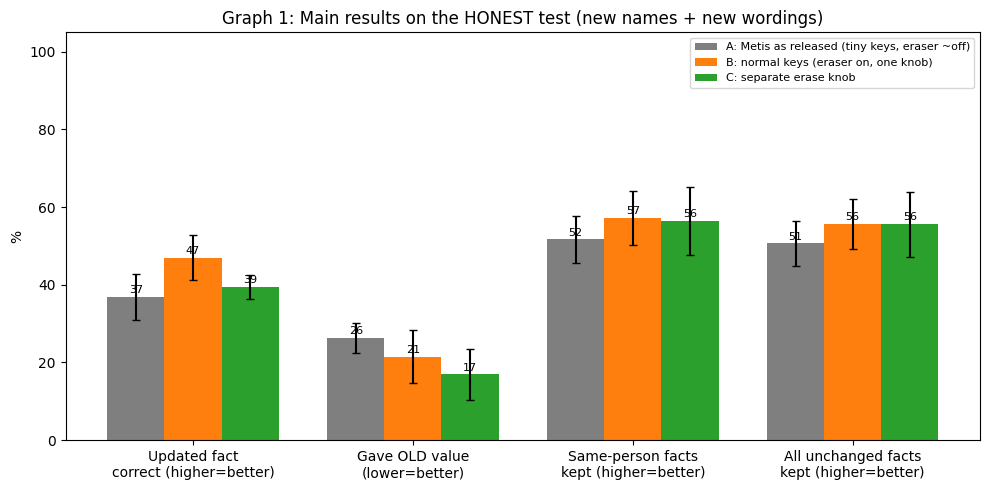

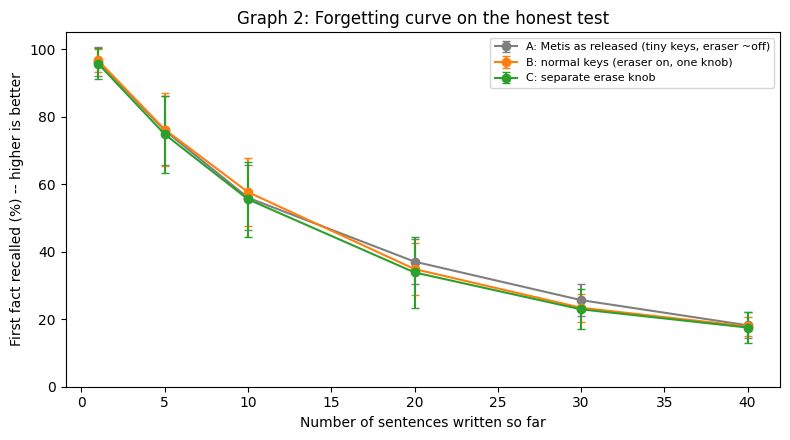

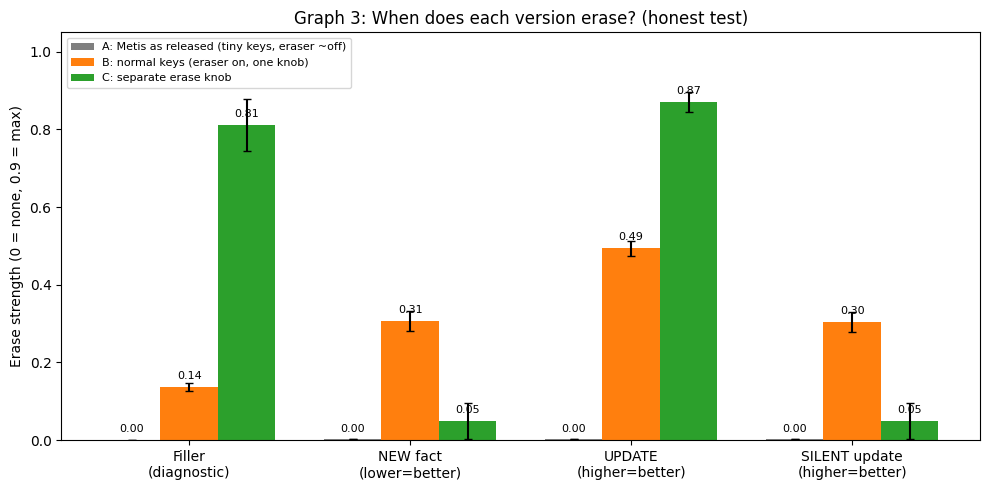

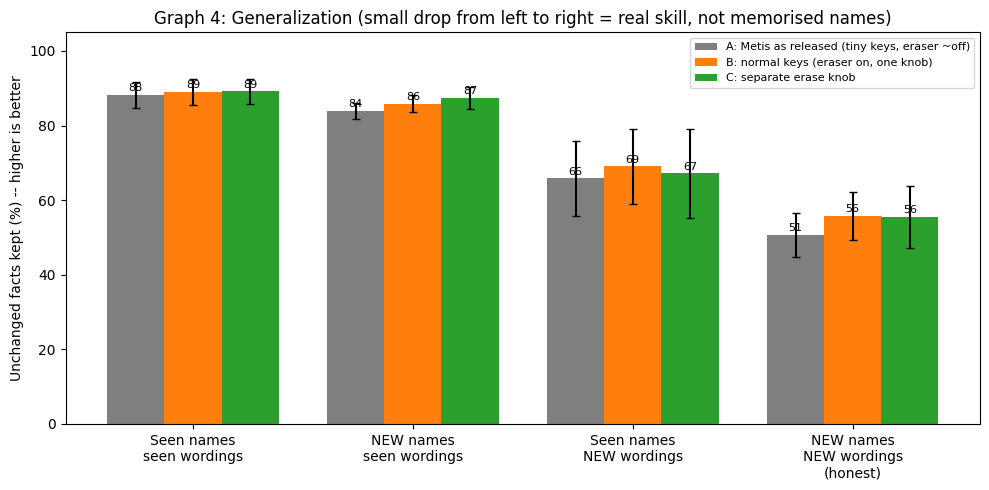

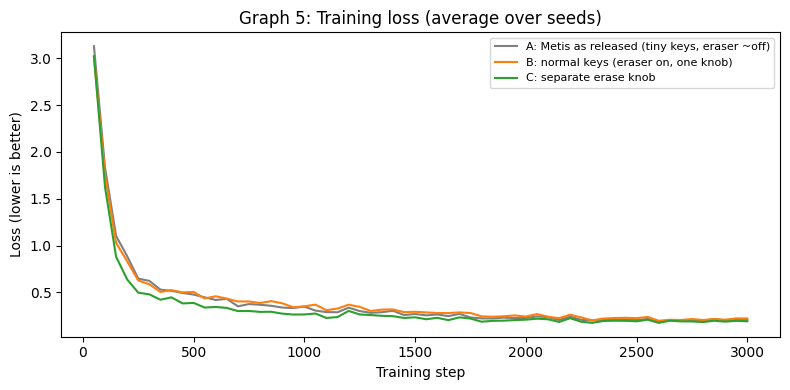

In [15]:
# CELL 15 -- Graphs
versions = CONFIG["versions"]
bar_width = 0.26


def bar_group(axis, metric_keys, labels, value_format="{:.0f}", offset_text=1.0):
    positions = np.arange(len(metric_keys))
    for version_index in range(len(versions)):
        version = versions[version_index]
        rows = results_table[results_table["version"] == version]
        means = [rows[key].mean() for key in metric_keys]
        stds = [rows[key].std() for key in metric_keys]
        offset = (version_index - 1) * bar_width
        bars = axis.bar(positions + offset, means, bar_width, yerr=stds, capsize=3,
                        label=VERSION_DESCRIPTIONS[version], color=VERSION_COLORS[version])
        for bar, mean_value in zip(bars, means):
            axis.text(bar.get_x() + bar.get_width() / 2, mean_value + offset_text, value_format.format(mean_value),
                      ha="center", fontsize=8)
    axis.set_xticks(positions)
    axis.set_xticklabels(labels)


# Graph 1: main metrics on the honest test
figure, axis = plt.subplots(figsize=(10, 5))
bar_group(axis, ["honest_update_correct", "honest_update_gave_old", "honest_same_person_kept", "honest_unchanged_kept"],
          ["Updated fact\ncorrect (higher=better)", "Gave OLD value\n(lower=better)",
           "Same-person facts\nkept (higher=better)", "All unchanged facts\nkept (higher=better)"])
axis.set_ylim(0, 105)
axis.set_ylabel("%")
axis.set_title("Graph 1: Main results on the HONEST test (new names + new wordings)")
axis.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph1_main_honest.png", dpi=150)
plt.show()

# Graph 2: forgetting curve
figure, axis = plt.subplots(figsize=(8, 4.5))
for version in versions:
    rows = results_table[results_table["version"] == version]
    means = [rows[f"long_first_after_{n}"].mean() for n in CONFIG["long_checkpoints"]]
    stds = [rows[f"long_first_after_{n}"].std() for n in CONFIG["long_checkpoints"]]
    axis.errorbar(CONFIG["long_checkpoints"], means, yerr=stds, marker="o", capsize=3,
                  label=VERSION_DESCRIPTIONS[version], color=VERSION_COLORS[version])
axis.set_xlabel("Number of sentences written so far")
axis.set_ylabel("First fact recalled (%) -- higher is better")
axis.set_ylim(0, 105)
axis.set_title("Graph 2: Forgetting curve on the honest test")
axis.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph2_forgetting_curve.png", dpi=150)
plt.show()

# Graph 3: erase strength by sentence type
figure, axis = plt.subplots(figsize=(10, 5))
bar_group(axis, ["honest_erase_on_filler", "honest_erase_on_new_fact", "honest_erase_on_update", "silent_erase_on_update"],
          ["Filler\n(diagnostic)", "NEW fact\n(lower=better)", "UPDATE\n(higher=better)", "SILENT update\n(higher=better)"],
          value_format="{:.2f}", offset_text=0.02)
axis.set_ylim(0, 1.05)
axis.set_ylabel("Erase strength (0 = none, 0.9 = max)")
axis.set_title("Graph 3: When does each version erase? (honest test)")
axis.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph3_erase_by_type.png", dpi=150)
plt.show()

# Graph 4: generalization -- unchanged facts kept under the four test conditions
figure, axis = plt.subplots(figsize=(10, 5))
bar_group(axis, [f"{condition}_unchanged_kept" for condition in CONDITION_ORDER],
          ["Seen names\nseen wordings", "NEW names\nseen wordings", "Seen names\nNEW wordings", "NEW names\nNEW wordings\n(honest)"])
axis.set_ylim(0, 105)
axis.set_ylabel("Unchanged facts kept (%) -- higher is better")
axis.set_title("Graph 4: Generalization (small drop from left to right = real skill, not memorised names)")
axis.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph4_generalization.png", dpi=150)
plt.show()

# Graph 5: training loss
figure, axis = plt.subplots(figsize=(8, 4))
for version in versions:
    curves = []
    for seed in CONFIG["seeds"]:
        key = f"{version}_seed{seed}"
        if key in LOSS_CURVES:
            curves.append([point["loss"] for point in LOSS_CURVES[key]])
    if len(curves) > 0:
        shortest = min(len(curve) for curve in curves)
        average_curve = np.mean([curve[:shortest] for curve in curves], axis=0)
        steps = [point["step"] for point in LOSS_CURVES[f"{version}_seed{CONFIG['seeds'][0]}"]][:shortest]
        axis.plot(steps, average_curve, label=VERSION_DESCRIPTIONS[version], color=VERSION_COLORS[version])
axis.set_xlabel("Training step")
axis.set_ylabel("Loss (lower is better)")
axis.set_title("Graph 5: Training loss (average over seeds)")
axis.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph5_loss.png", dpi=150)
plt.show()

In [16]:
# CELL 16 -- Verdict using the rules written in CONFIG BEFORE seeing any results (all on the HONEST test)


def mean_of(version, column):
    return results_table[results_table["version"] == version][column].mean()


A_update, B_update, C_update = [mean_of(v, "honest_update_correct") for v in ["A", "B", "C"]]
A_same, B_same, C_same = [mean_of(v, "honest_same_person_kept") for v in ["A", "B", "C"]]
A_kept, B_kept, C_kept = [mean_of(v, "honest_unchanged_kept") for v in ["A", "B", "C"]]
A_long, B_long, C_long = [mean_of(v, "long_first_after_40") for v in ["A", "B", "C"]]
A_old, B_old, C_old = [mean_of(v, "honest_update_gave_old") for v in ["A", "B", "C"]]
C_erase_update, C_erase_new = mean_of("C", "honest_erase_on_update"), mean_of("C", "honest_erase_on_new_fact")
C_erase_silent = mean_of("C", "silent_erase_on_update")

checks = [
    ("0. Memory generalises: every version keeps >= %.0f%% of unchanged facts on the honest test" % CONFIG["generalization_floor"],
     min(A_kept, B_kept, C_kept) >= CONFIG["generalization_floor"], f"A {A_kept:.1f}% | B {B_kept:.1f}% | C {C_kept:.1f}%"),
    ("1. Problem exists: B (working eraser) beats A on updates by >= %.0f points" % CONFIG["problem_threshold"],
     B_update - A_update >= CONFIG["problem_threshold"], f"B {B_update:.1f}% vs A {A_update:.1f}%"),
    ("2. Idea helps updates: C beats A on updates by >= %.0f points" % CONFIG["gain_threshold"],
     C_update - A_update >= CONFIG["gain_threshold"], f"C {C_update:.1f}% vs A {A_update:.1f}%"),
    ("3. Idea is safe: C keeps same-person facts as well as A (within %.0f points)" % CONFIG["damage_tolerance"],
     C_same >= A_same - CONFIG["damage_tolerance"], f"C {C_same:.1f}% vs A {A_same:.1f}%"),
    ("4. Idea beats the simple fix: C keeps same-person facts better than B (by > %.0f points)" % CONFIG["damage_tolerance"],
     C_same > B_same + CONFIG["damage_tolerance"], f"C {C_same:.1f}% vs B {B_same:.1f}%"),
    ("5. C learned WHEN to erase: erases more than twice as much on updates as on new facts",
     C_erase_update > 2 * C_erase_new, f"update {C_erase_update:.3f} vs new fact {C_erase_new:.3f}"),
    ("6. Re-test of Notebook 2: C recalls the first fact after 40 writes better than B (by >= %.0f points)" % CONFIG["retention_margin"],
     C_long - B_long >= CONFIG["retention_margin"], f"C {C_long:.1f}% vs B {B_long:.1f}%"),
    ("7. C's gate reads MEANING: erase on silent updates is at least half of erase on normal updates",
     C_erase_silent >= 0.5 * C_erase_update, f"silent {C_erase_silent:.3f} vs normal {C_erase_update:.3f}"),
]

print("=" * 96)
print("VERDICT (rules fixed in CONFIG before running; all numbers from the HONEST test)")
print("=" * 96)
for description, passed_check, numbers in checks:
    print(f"[{'PASS' if passed_check else 'FAIL'}] {description}\n        {numbers}")
print(f"\nGave the OLD value (lower is better): A {A_old:.1f}% | B {B_old:.1f}% | C {C_old:.1f}%")

passed = {index: checks[index][1] for index in range(len(checks))}

print("\nWHAT THIS MEANS:")
if not passed[0]:
    print("The memory still does not generalise well enough to new names/wordings. Treat checks 1-7 as")
    print("unreliable and fix generalisation first (Table 2 shows whether names or wordings are the problem).")
elif passed[1] and passed[2] and passed[3] and passed[4]:
    print("Your direction is SUPPORTED: the released design struggles with updates, the simple fix (B)")
    print("damages other facts, and the separate erase knob (C) gets both right.")
elif passed[1] and passed[2] and passed[3] and not passed[4]:
    print("PARTLY supported: the problem is real and C fixes it safely, but the simple fix (B) is just as safe")
    print("on same-person facts. Look at check 6 and Graph 2: C's advantage may be long-range retention instead.")
elif not passed[1]:
    print("The update problem is SMALL in this setting: A handles updates nearly as well as B.")
    print("Look at 'Gave the OLD value', check 6 and Graph 2 -- the difference may show up as stale answers")
    print("or long-range forgetting rather than update accuracy.")
else:
    print("MIXED result: read the individual checks above and Graphs 1-3 before deciding.")
if passed[0] and not passed[5]:
    print("Note: C did not clearly learn to erase more on updates than on new facts (check 5).")
if passed[0] and passed[5] and not passed[7]:
    print("Note: C's erase gate mainly reacts to update WORDS, not to the meaning of a change (check 7).")
    print("That is an honest limitation and motivates a gate that also looks at what is already in memory.")

with open(f"{OUTPUT_DIR}/verdict.json", "w") as file:
    json.dump({"checks": [{"check": c[0], "passed": bool(c[1]), "numbers": c[2]} for c in checks]}, file, indent=2)
print("\nSaved everything in", OUTPUT_DIR)

VERDICT (rules fixed in CONFIG before running; all numbers from the HONEST test)
[FAIL] 0. Memory generalises: every version keeps >= 60% of unchanged facts on the honest test
        A 50.6% | B 55.7% | C 55.5%
[PASS] 1. Problem exists: B (working eraser) beats A on updates by >= 10 points
        B 47.0% vs A 36.9%
[FAIL] 2. Idea helps updates: C beats A on updates by >= 10 points
        C 39.5% vs A 36.9%
[PASS] 3. Idea is safe: C keeps same-person facts as well as A (within 3 points)
        C 56.4% vs A 51.7%
[FAIL] 4. Idea beats the simple fix: C keeps same-person facts better than B (by > 3 points)
        C 56.4% vs B 57.2%
[PASS] 5. C learned WHEN to erase: erases more than twice as much on updates as on new facts
        update 0.871 vs new fact 0.049
[FAIL] 6. Re-test of Notebook 2: C recalls the first fact after 40 writes better than B (by >= 5 points)
        C 17.5% vs B 17.9%
[FAIL] 7. C's gate reads MEANING: erase on silent updates is at least half of erase on normal u

In [17]:
# CELL 17 -- A human-readable example: what do A, B and C answer on one HONEST-test story?
demo_episode = TEST_SETS["honest"][0]
print("STORY (new names, new wordings):")
for step_number in range(len(demo_episode["writes"])):
    write = demo_episode["writes"][step_number]
    print(f"  {step_number + 1:2d}. {ALL_SENTENCES[write['sid']]}")

demo_batch = standard_episodes_to_batch([demo_episode])
demo_answers = {}
for version in CONFIG["versions"]:
    model = NativeMemory(FEATURE_SIZE, CONFIG["memory_size"], len(ANSWERS), version).to(DEVICE)
    model.load_state_dict(torch.load(f"{OUTPUT_DIR}/model_{version}_seed{CONFIG['seeds'][0]}.pt", map_location=DEVICE))
    model.eval()
    with torch.no_grad():
        logits, _ = run_standard_batch(model, demo_batch)
    demo_answers[version] = [ANSWERS[index] for index in logits.argmax(dim=-1)[0].tolist()]

print("\nQUESTIONS:")
for query_number in range(len(demo_episode["queries"])):
    query = demo_episode["queries"][query_number]
    marker = "  <-- UPDATED" if query["updated"] else ""
    print(f"\n  {ALL_SENTENCES[query['sid']]}  (correct: {query['answer']}){marker}")
    for version in CONFIG["versions"]:
        answer = demo_answers[version][query_number]
        tick = "✓" if answer == query["answer"] else "✗"
        print(f"     {VERSION_DESCRIPTIONS[version]:48s} -> {answer:12s} {tick}")

STORY (new names, new wordings):
   1. The soup needed more salt.
   2. Elena Chowdhury's top dish is pasta.
   3. Rina Takahashi makes a career as an architect.
   4. Rina Takahashi's top dish is sushi.
   5. Elena Chowdhury prefers the color beige.
   6. Elena Chowdhury's address is in Mumbai.
   7. Rina Takahashi resides in Paris.
   8. Elena Chowdhury is employed as a pilot.
   9. Elena Chowdhury has grown tired of the old dish and now craves curry.
  10. Someone knocked on the door.
  11. Rina Takahashi is the proud owner of a rabbit.
  12. The library was quiet.

QUESTIONS:

  Which color is Elena Chowdhury drawn to?  (correct: beige)
     A: Metis as released (tiny keys, eraser ~off)    -> Paris        ✗
     B: normal keys (eraser on, one knob)             -> Paris        ✗
     C: separate erase knob                           -> Tokyo        ✗

  What food does Elena Chowdhury love most?  (correct: curry)  <-- UPDATED
     A: Metis as released (tiny keys, eraser ~off)    -> cu

In [18]:
# CELL 18 -- Pack the results (tables, graphs, json) into one small zip to download
# Model weights (.pt) and the big features file are left out to keep the zip small.
results_folder = "/kaggle/working/notebook3_results"
if os.path.exists(results_folder):
    shutil.rmtree(results_folder)
os.makedirs(results_folder)
for file_name in os.listdir(OUTPUT_DIR):
    if file_name.endswith((".json", ".csv", ".png")):
        shutil.copy(os.path.join(OUTPUT_DIR, file_name), results_folder)
zip_path = shutil.make_archive("/kaggle/working/notebook3_results", "zip", results_folder)
print("Download this file:", zip_path)
print("Contains:", sorted(os.listdir(results_folder)))

Download this file: /kaggle/working/notebook3_results.zip
Contains: ['graph1_main_honest.png', 'graph2_forgetting_curve.png', 'graph3_erase_by_type.png', 'graph4_generalization.png', 'graph5_loss.png', 'loss_curves.json', 'results.json', 'table1_main_honest.csv', 'table2_generalization.csv', 'table3_erase.csv', 'table4_silent_updates.csv', 'table5_forgetting_curve.csv', 'table6_paired_differences.csv', 'verdict.json']
